> ## ⚠️ Antes de ejecutar en Google Colab
>
> ### 🖥️ Activá la GPU: *Entorno de ejecución → Cambiar tipo de entorno → **GPU T4** → Guardar.*
> Sin la GPU, la generación del modelo corre en CPU y **no termina** (da *timeout*).
>
> ### ⏳ Tené paciencia: la generación tarda unos minutos.
> Bajar el modelo `qwen2.5:14b` (~9 GB) y generar los artefactos lleva **unos minutos** — es
> normal, dejalo correr. La celda de la demo con/sin RAG es la más lenta (hace varias llamadas
> al modelo).
>
> *Flujo:* GPU T4 → *Ejecutar todo* → la 2ª celda te pedirá subir el zip de la entrega y se
> descomprime sola.

# Generador Académico RAG — Notebook integrador
**TP Integrador de Ciencia de Datos · UTN FRLP 2026 · Grupo 14**

Sistema de IA generativa que, alimentado por una base vectorial con el **historial académico
real** del grupo + el **plan de estudios** de la carrera, genera *artefactos académicos
personalizados* (planes de cursada, informes, cartas de pasantía, recomendaciones,
diagnóstico grupal, simulaciones). No responde preguntas: **sintetiza documentos nuevos**
anclados en datos privados que el modelo no conoce.

### Por qué es generativo y no un SQL
Un SQL te dice *qué* materias podés cursar (lookup). Esto te dice *qué conviene y por qué*,
redactado, con tono controlable, cruzando notas + correlativas + rendimiento. La salida es
texto nuevo sintetizado, no un campo de una tabla.

### Pipeline (lo construimos nosotros, no es NotebookLM)
```
PDFs ──pdfplumber──▶ documentos (estructurado + no estructurado)
     ──MiniLM──▶ embeddings ──▶ Chroma (base vectorial)
     ──retrieval top-k──▶ contexto ──▶ qwen2.5:14B (Ollama) ──▶ artefacto
```
El pipeline RAG corre **local**; la **generación** corre en una GPU (en Colab, la T4 gratuita).
Si el LLM está apagado, la parte RAG funciona igual (recupera el contexto) y la generación se
completa al encender el modelo.

## 0 · Setup

La primera celda de código (*bootstrap*) corre **solo en Colab**: pide subir el zip de la entrega y
lo descomprime para dejar el proyecto en su lugar. La celda siguiente prepara el entorno: **en
Colab** (recomendado *Entorno de ejecución → GPU T4*) instala las dependencias y levanta el modelo
en la GPU para ver la generación en vivo; **en local**, con el repo ya presente, solo agrega `src/`
al path.

> El notebook necesita correr junto a `src/` y `data/raw/`. En local, abrilo desde la carpeta del
> proyecto. En Colab, el *bootstrap* se encarga (subís el zip y listo). Si no hay GPU, el pipeline
> corre igual en modo solo-retrieval; solo la generación del LLM requiere GPU.

In [ ]:
# Bootstrap (solo Colab): si el proyecto no está presente, pide el .zip de la entrega y lo descomprime.
# En local no hace nada (ya estás parado en la carpeta del proyecto).
import sys, os
from pathlib import Path

if "google.colab" in sys.modules and not Path("src").exists():
    import zipfile
    from google.colab import files
    print("Subí el zip de la entrega (Entrega-Grupo14-GeneradorAcademico.zip)…")
    subido = files.upload()
    znombre = next(n for n in subido if n.endswith(".zip"))
    with zipfile.ZipFile(znombre) as z:
        z.extractall()
        raiz = z.namelist()[0].split("/")[0]   # carpeta raíz dentro del zip
    os.chdir(raiz)
    print("Descomprimido. Carpeta de trabajo:", os.getcwd())

In [ ]:
import os, sys, subprocess, time
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if not Path("src").exists():
    raise RuntimeError(
        "No encuentro 'src/'. Corré este notebook DESDE la carpeta del proyecto "
        "(con src/ y data/raw/). En Colab: subí el proyecto a Drive y abrí el .ipynb desde ahí.")

if EN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
    # LLM en la GPU de Colab para ver la generación. Si falla (sin GPU), seguimos en solo-retrieval.
    MODELO = os.environ.get("OLLAMA_MODEL", "qwen2.5:14b-instruct")  # mismo modelo que la web app
    try:
        subprocess.run("apt-get -qq install -y zstd pciutils", shell=True, check=True)
        subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, check=True)
        os.environ["OLLAMA_HOST"] = "0.0.0.0:11434"
        subprocess.Popen(["ollama", "serve"]); time.sleep(5)
        subprocess.run(["ollama", "pull", MODELO], check=True)
        os.environ["OLLAMA_MODEL"] = MODELO
    except Exception as e:
        print("No se pudo levantar Ollama en Colab (¿sin GPU?); sigo en modo solo-retrieval:", e)

sys.path.insert(0, str(Path.cwd() / "src"))  # importar los módulos del proyecto
import analisis, documents, extract, figuras, generar, ingest, rag, evaluar
from IPython.display import Image, display

print("Modelo:", rag.OLLAMA_MODEL, "|", "ENCENDIDO" if rag.ollama_disponible() else "apagado (solo-retrieval)")

## 1 · Extracción de los PDFs
`extract.pdf_to_text` usa **pdfplumber**. La fuente son estados académicos reales, exports de
notas de exámenes y el plan de estudios 2023 (correlatividades + equivalencias).

In [2]:
raw = documents.RAW_DIR
print("PDFs disponibles:", [p.name for p in sorted(raw.glob("*.pdf"))])
texto = extract.pdf_to_text(raw / "Plan-Sistemas-2023.pdf")
print(f"\nPlan 2023: {len(texto)} caracteres. Primeras líneas:\n")
print("\n".join(texto.splitlines()[:8]))

PDFs disponibles: ['Estado-Academico-Bauti.pdf', 'Estado-Academico-Lauti.pdf', 'Estado-Academico-Mora.pdf', 'Estado-Academico-Santi.pdf', 'Estado-Academico-Simon.pdf', 'Estado-Academico-Tomi.pdf', 'Notas-Bauti.pdf', 'Notas-Lauti.pdf', 'Notas-Mora.pdf', 'Notas-Santi.pdf', 'Notas-Simon.pdf', 'Notas-Tomi.pdf', 'Plan-Sistemas-2008.pdf', 'Plan-Sistemas-2023.pdf']



Plan 2023: 13208 caracteres. Primeras líneas:

“Las “Las Malvinas son argentinas”
Ministerio de Educación
Universidad Tecnológica Nacional
PABLO A. HUEL
Rectorado JEFE DE DEPARTAMENTO
APOYO AL CONSEJO SUPERIOR
RÉGIMEN DE CORRELATIVIDADES, EQUIVALENCIAS PARA MATERIAS
DE LA CARRERA INGENIERÍA EN SISTEMAS DE INFORMACIÓN


## 2 · Construcción del corpus
`documents.construir_corpus` fusiona lo **estructurado** (una entrada por materia con nota,
año, alumno) con lo **no estructurado** (chunks del plan) y parsea las **36 correlatividades**.
La clave de join entre estado y plan es el *nombre normalizado* (`normalizar`), porque los
códigos institucionales no coinciden entre documentos.

In [3]:
corpus = documents.construir_corpus()
print(f"Total documentos en el corpus: {len(corpus)}")
from collections import Counter
print("Por fuente:", dict(Counter(d["metadata"]["fuente"] for d in corpus)))

print("\nEjemplo (estado académico):")
ej = next(d for d in corpus if d["metadata"]["fuente"] == "estado_academico" and d["metadata"]["nota"] >= 0)
print(" texto:", ej["text"])
print(" metadata:", ej["metadata"])

Total documentos en el corpus: 439
Por fuente: {'estado_academico': 383, 'plan_estudios': 20, 'correlatividades': 36}

Ejemplo (estado académico):
 texto: Juan Cuenca, en la carrera Ingeniería en Sistemas de Información (Plan 2023), con la materia 'Algoritmos y Estructuras de Datos' (código 106, año 1 de la carrera): Aprobada con 8 (5 hs.) Tomo: 386 Folio: 2.
 metadata: {'fuente': 'estado_academico', 'alumno': 'Juan Cuenca', 'materia': 'Algoritmos y Estructuras de Datos', 'codigo': '106', 'anio': 1, 'nota': 8, 'estado': 'Aprobada con 8 (5 hs.) Tomo: 386 Folio: 2'}


## 3 · Embeddings + base vectorial Chroma
`ingest.reindexar` vectoriza el corpus con **all-MiniLM-L6-v2** (el embedding por defecto de
Chroma, local y offline) y lo persiste. Esta es la base que el modelo consultará.

In [4]:
n = ingest.reindexar()
print(f"Indexados {n} documentos en Chroma → {ingest.CHROMA_DIR}")

Indexados 439 documentos en Chroma → C:\Users\Simon Ocampo\OneDrive - UTN FRLP\Facultad\Ingenieria en Sistemas\Materias\5to\Ciencia de Datos\Practica\TP Grupal\generador-academico-rag\data\chroma


## 4 · Retrieval
Dos modos de recuperación:
- **Semántico** (`ingest.buscar`): similitud de embeddings, para preguntas en lenguaje natural.
- **Determinístico** (`ingest.obtener`): por metadata, para grounding exacto (las materias
  aprobadas de un alumno, las correlatividades). Es lo que ancla a los generadores.

In [5]:
print("### Búsqueda semántica: '¿qué necesito para cursar Ciencia de Datos?'")
for r in ingest.buscar("¿qué necesito para cursar Ciencia de Datos?", k=3):
    print(f"  [{r['distancia']:.3f}] ({r['metadata']['fuente']}) {r['text'][:90]}")

print("\n### Grounding determinístico: materias aprobadas de un alumno (por metadata)")
aprobadas = ingest.obtener({"$and": [{"fuente": "estado_academico"}, {"alumno": "Simón Ocampo"}]})
aprobadas = [d for d in aprobadas if d["metadata"]["nota"] >= 0]
print(f"  {len(aprobadas)} materias con nota. Ejemplos:", [d["metadata"]["materia"] for d in aprobadas[:5]])

### Búsqueda semántica: '¿qué necesito para cursar Ciencia de Datos?'


  [0.517] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Ciencia de Datos' es la materia
  [0.674] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Redes de Datos' es la materia N
  [0.687] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Comunicación de Datos' es la ma

### Grounding determinístico: materias aprobadas de un alumno (por metadata)
  39 materias con nota. Ejemplos: ['Algoritmos y Estructuras de Datos', 'Análisis Matemático I', 'Arquitectura de Computadoras', 'Física I', 'Inglés I']


## 5 · EDA + visualización
`analisis` arma un DataFrame de notas **reales de los 6 integrantes del grupo**, fusionando el
estado académico de cada uno con su export de exámenes. Cada registro es `(alumno, materia, año,
nota, área)`; las áreas temáticas mapean las 36 obligatorias del plan en 6 grupos.

In [6]:
real = analisis.tabla_real()
print(f"Registros reales: {len(real)} | alumnos: {real['alumno'].nunique()}")
display(analisis.promedio_por_alumno(real).to_frame("promedio"))

grupo = analisis.tabla_grupo()  # los 6 integrantes, todos con datos reales
perfil = analisis.perfil_por_area(grupo)
print("\nPerfil por área (nota media) — los 6 integrantes:")
display(perfil)

Registros reales: 220 | alumnos: 6


,promedio
alumno,
Mora Gentil,8.68
Lautaro Aubert,8.50
Simón Ocampo,8.46
Juan Cuenca,8.11
Santiago Natalichio,8.11
Tomas Martin,8.00



Perfil por área (nota media) — los 6 integrantes:


area,Datos e Inteligencia,Idiomas,Infraestructura y Redes,Matemática y Física,Otras,Programación,Sistemas y Gestión
alumno,,,,,,,
Juan Cuenca,7.5,10.0,8.0,8.38,7.71,7.6,8.25
Lautaro Aubert,7.0,9.5,8.0,9.00,8.17,8.8,8.25
Mora Gentil,8.5,9.0,8.2,8.75,8.57,8.8,8.88
Santiago Natalichio,7.5,9.5,7.4,8.25,8.00,7.4,8.75
Simón Ocampo,9.0,9.0,8.0,8.62,8.56,8.2,8.38
Tomas Martin,8.5,6.5,7.4,7.88,8.14,8.2,8.50


findfont: Failed to find font weight 600, now using 400.


Generando figuras en C:\Users\Simon Ocampo\OneDrive - UTN FRLP\Facultad\Ingenieria en Sistemas\Materias\5to\Ciencia de Datos\Practica\TP Grupal\generador-academico-rag\figs


  [ok] notas_distribucion.png


  [ok] avance_anual.png


  [ok] radar_areas.png


  [ok] clustering_perfiles.png


  [ok] materias_embeddings.png


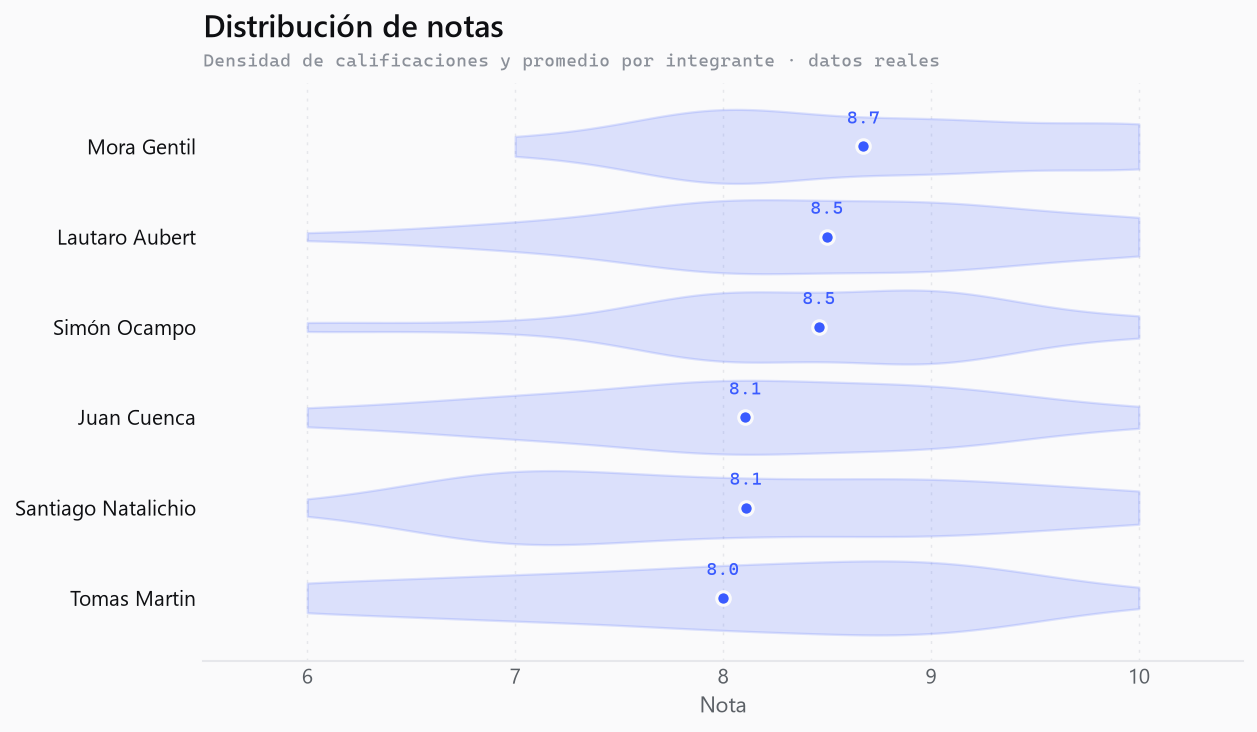

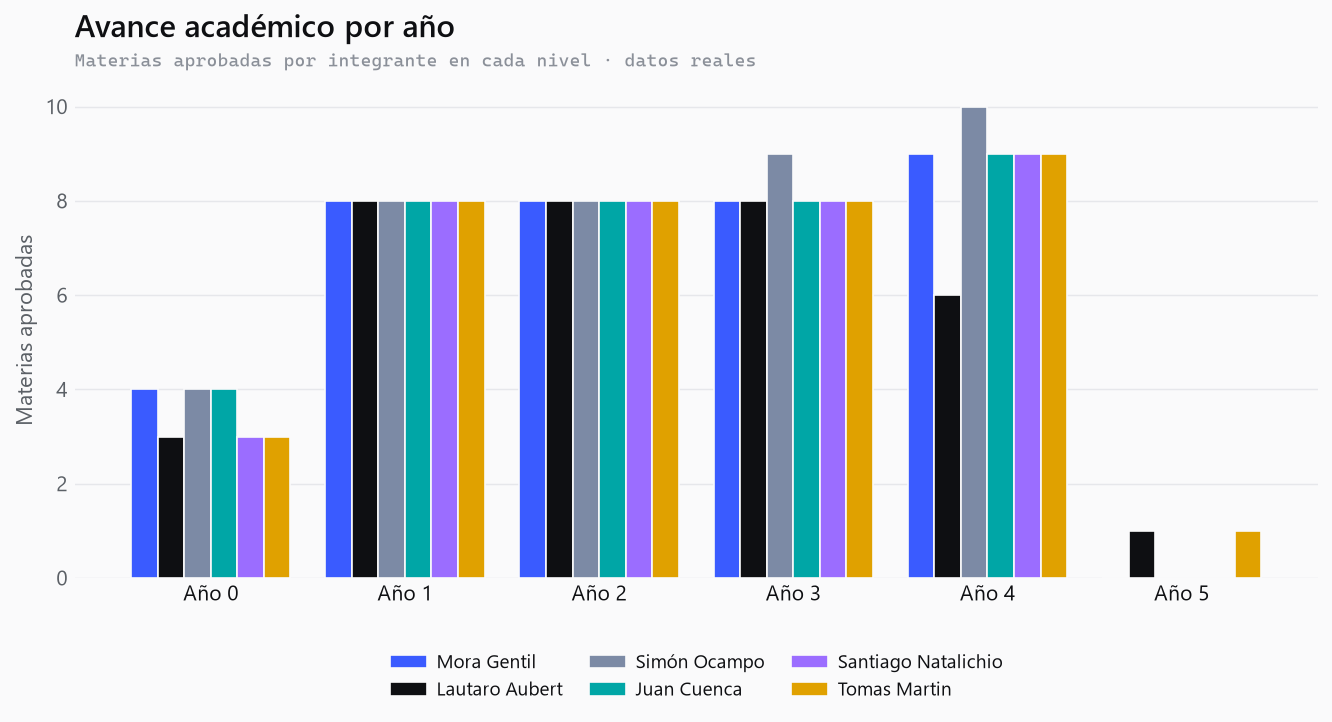

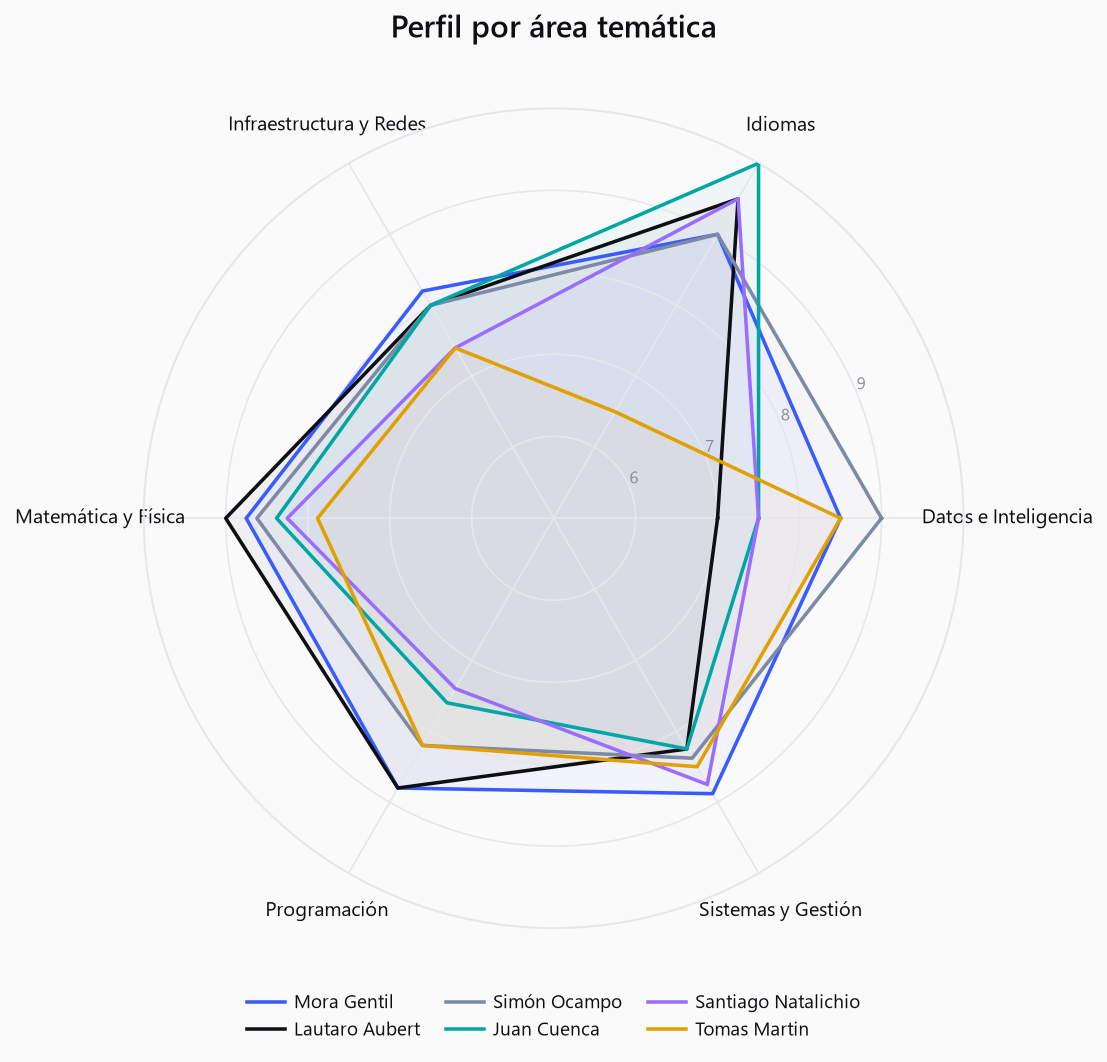

In [7]:
figuras.generar_todo()  # regenera los PNG con estilo Graphite & Cobalt
for png in ["notas_distribucion.png", "avance_anual.png", "radar_areas.png"]:
    display(Image(filename=str(figuras.FIGS / png)))

## 6 · Clustering de perfiles
KMeans sobre el perfil por área (estandarizado), proyectado a 2D con PCA. Y, aparte, las 36
obligatorias proyectadas con **t-SNE de sus embeddings**: las materias de la misma área caen
juntas, lo que valida que el espacio semántico capturó la estructura del plan.

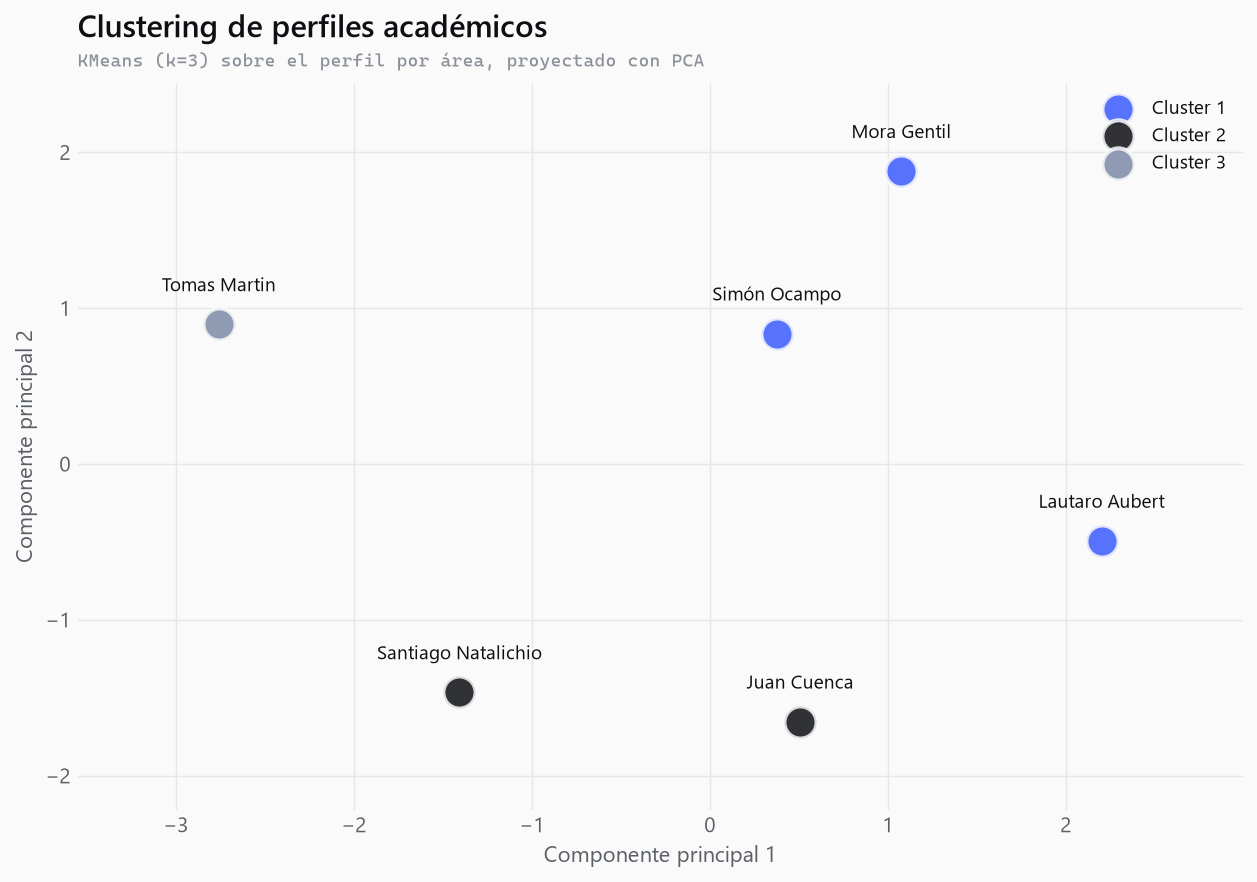

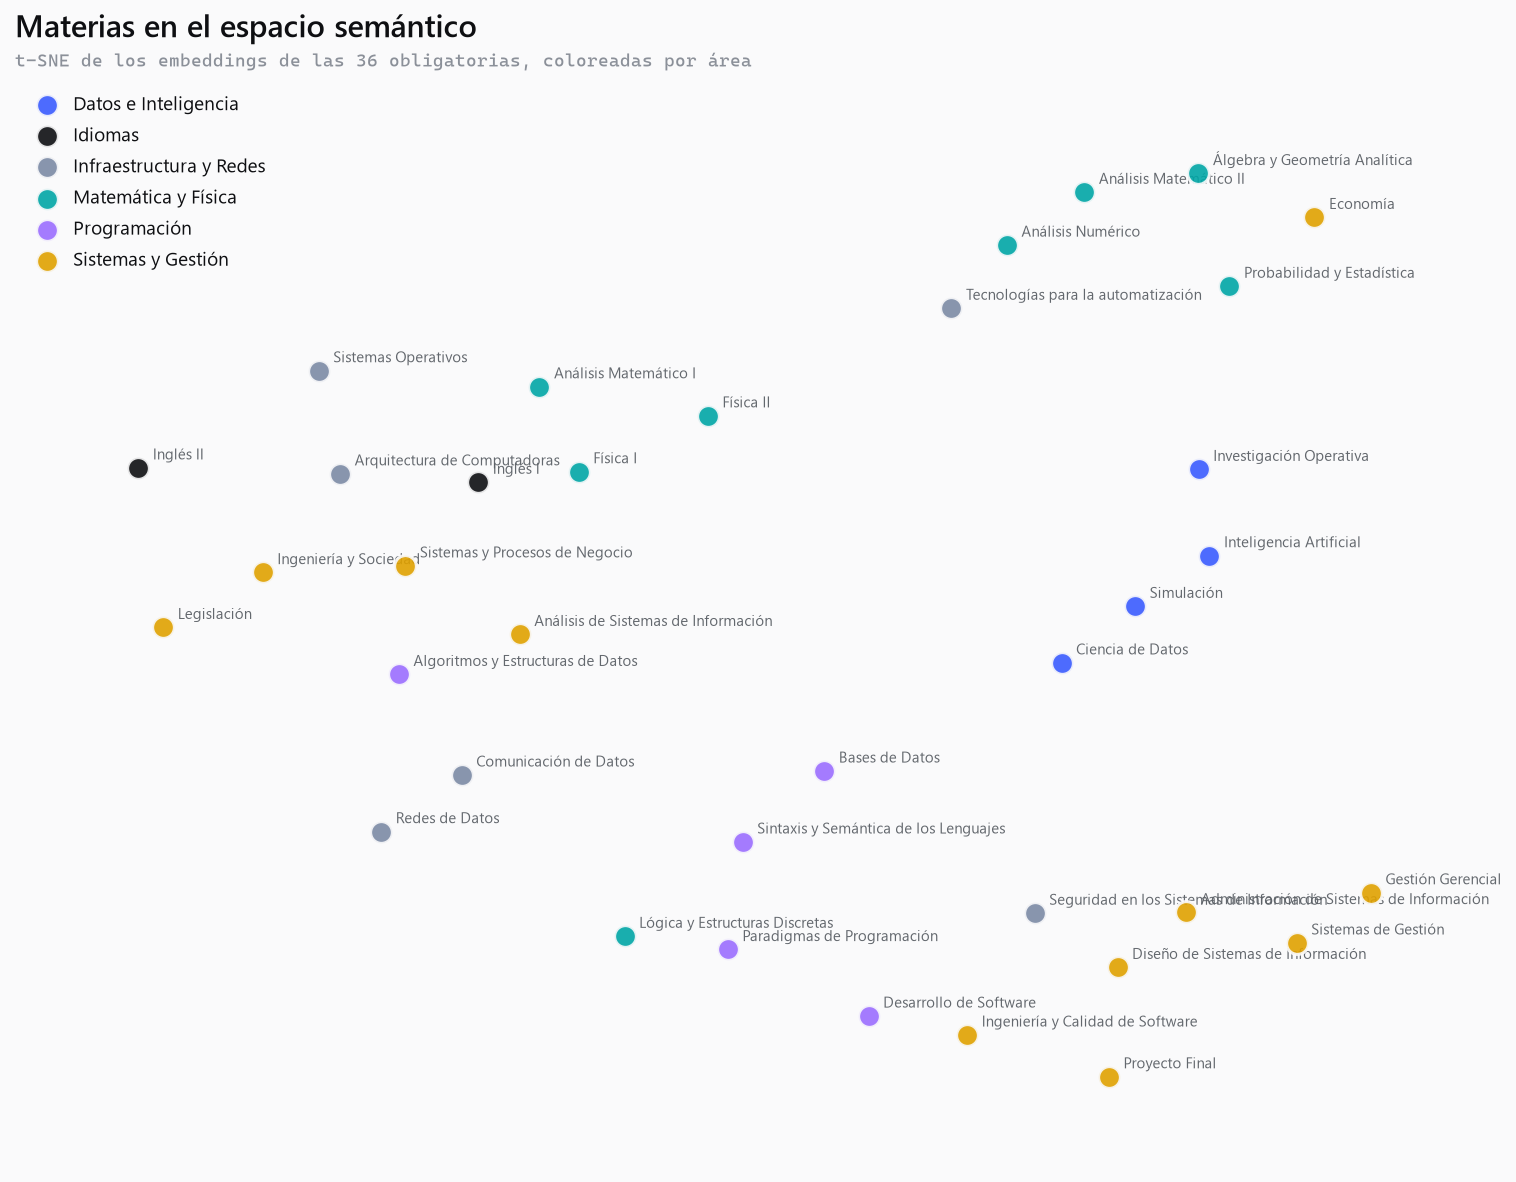

In [8]:
display(Image(filename=str(figuras.FIGS / "clustering_perfiles.png")))
display(Image(filename=str(figuras.FIGS / "materias_embeddings.png")))

## 7 · Generación de artefactos con tono
Cada generador ancla la salida en el contexto recuperado (grounding) y pasa **solo ese
contexto** al LLM. El **tono** (técnico / motivacional / honesto) cambia el registro sobre los
mismos datos: eso es lo que lo hace generativo y no un reporte fijo.

In [9]:
art = generar.plan_cursada("Simón Ocampo", tono="tecnico")
print("Artefacto:", art["artefacto"], "| fuente:", art["fuente"])
print(f"\nCONTEXTO recuperado ({len(art['contexto'])} chars), primeras líneas:")
print("\n".join(art["contexto"].splitlines()[:6]))

print("\n--- SALIDA ---")
if art["salida"]:
    print(art["salida"])
else:
    print("(Ollama apagado) El contexto de arriba ya es la parte RAG. Encendé el modelo para la generación.")

Artefacto: plan_cursada | fuente: ollama

CONTEXTO recuperado (2559 chars), primeras líneas:
RENDIMIENTO de Simón Ocampo (materias aprobadas con su nota y año):
- Algoritmos y Estructuras de Datos (nota 8, año 1)
- Análisis Matemático I (nota 9, año 1)
- Arquitectura de Computadoras (nota 8, año 1)
- Física I (nota 9, año 1)
- Inglés I (nota 9, año 1)

--- SALIDA ---
### Plan de cursada para Simón Ocampo

#### Materias Obligatorias:
1. **Seguridad en los Sistemas de Información**
   - Justificación: Esta materia es una obligatoria habilitada por materias ya aprobadas, como Redes de Datos y Administración de Sistemas de Información. Es fundamental para avanzar en la carrera.
   
#### Materias Electivas:
2. **Aplicaciones Móviles**
   - Justificación: Simón tiene una buena nota en Desarrollo De Aplicaciones Moviles (Elec.) con un 8, lo que indica afinidad y capacidad técnica en esta área.

3. **Tecnologías de Interfaces Interactivas**
   - Justificación: Esta materia se relaciona directa

## 8 · Evaluación — con/sin RAG (demo estrella)
Medimos el anclaje con **cuatro métricas sobre tres ejes**:
- **Solapamiento** — *grounding léxico* (fracción de tokens informativos de la salida presentes
  literalmente en el contexto; penaliza paráfrasis) y *grounding semántico* (máximo coseno de
  embeddings salida↔contexto; reconoce la reformulación legítima).
- **Corrección factual** — *precisión factual*: extrae los pares (materia, nota) que la salida
  afirma y verifica cada uno contra el registro real del alumno. Mide acierto, no cercanía.
- **Juicio de un LLM** — *faithfulness*: el propio modelo puntúa 0–1 cuánto se apoya la respuesta
  solo en el contexto (LLM-as-judge).

El mismo pedido CON RAG vs SIN RAG hace medible el aporte del conocimiento privado.

In [10]:
# Validación rápida de las métricas léxica/factual sobre un caso de juguete (no requiere LLM)
contexto = ("- Simón Ocampo aprobó Bases de Datos con 9 en el año 3.\n"
            "- Simón Ocampo aprobó Análisis Matemático I con 9 en el año 1.")
anclada = "Simón rindió Bases de Datos con 9 y Análisis Matemático I con 9, muy buen desempeño."
inventada = "Recomiendo cursar Astrofísica Cuántica y Derecho Romano el próximo cuatrimestre."
print("léxico    — anclada:", evaluar.grounding_score(anclada, contexto),
      "| inventada:", evaluar.grounding_score(inventada, contexto))
registro = {"bases de datos": 9, "analisis matematico i": 9}
print("precisión — anclada:", evaluar.precision_factual(anclada, registro)["precision"],
      "| inventada:", evaluar.precision_factual(inventada, registro))

léxico    — anclada: 1.0 | inventada: 0.0
precisión — anclada: 1.0 | inventada: None


In [11]:
# Demo estrella CON vs SIN RAG sobre un artefacto real (requiere el LLM encendido)
if rag.ollama_disponible():
    cmp = evaluar.comparar_con_sin_rag(generar.recomendar_orientacion, alumno="Mora Gentil")
    con, sin = cmp["con_rag"], cmp["sin_rag"]
    pf = (con.get("precision_factual") or {}).get("precision")
    print(f"grounding léxico    CON={con['grounding']}  SIN={sin['grounding']}")
    print(f"grounding semántico CON={con['grounding_sem']}  SIN={sin['grounding_sem']}")
    print(f"precisión factual   CON={pf}  SIN={(sin.get('precision_factual') or {}).get('precision')}")
    print(f"faithfulness (juez) CON={con.get('faithfulness')}  SIN={sin.get('faithfulness')}")
    print("\nResultados agregados (4 artefactos) en data/eval_resultados.json; ver scripts/run_eval.py")
else:
    print("(LLM apagado) Encendé el modelo (celda 0 en Colab) para la comparación con/sin RAG.")

grounding léxico    CON=0.75  SIN=0.321
grounding semántico CON=0.656  SIN=0.531
precisión factual   CON=None  SIN=None
faithfulness (juez) CON=0.8  SIN=0.0

Resultados agregados (4 artefactos) en data/eval_resultados.json; ver scripts/run_eval.py


## 9 · Conclusiones
- Construimos el **pipeline RAG completo** (extracción, corpus mixto, embeddings, Chroma,
  retrieval, generación) en vez de usar una caja negra.
- El sistema **genera** artefactos personalizados con tono, no responde preguntas: cada salida
  es contenido nuevo anclado en datos privados.
- La **demo con/sin RAG** y las **cuatro métricas** (léxico, semántico, precisión factual y
  faithfulness) hacen medible el aporte del conocimiento privado: con RAG la precisión factual es
  1.0 (cero notas inventadas); sin RAG el modelo no puede anclar.
- Pipeline de Ciencia de Datos completo: EDA, visualización, clustering y evaluación.

La web app (`iniciar.bat` local, o `iniciar-colab.bat` apuntando a la GPU de Colab) permite probar
todo esto en vivo, con la consola de contexto y el medidor de grounding en tiempo real.